# Results

## Librairies

In [157]:
import os
import ast

import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Read results

In [285]:
results_folder = "."
file_name = f"results_0_all_testsubset_[1]_p=0.9_nlp.csv"

In [286]:
match = re.search(r"results_(\d+).*?\[(\d+)\]_p=([\d.]+)", file_name)
if match:
    c = int(match.group(2))  # 1
    p = float(match.group(3))           # 0.7
c, p

(1, 0.9)

In [287]:
results_df = pd.read_csv(file_name)
results_df = results_df.sort_values(by="error_polytope")
results_df = results_df.reset_index(drop=True) # reset index

In [288]:
results_df

,error_x0_a,error_x0_b,error_x0_c,error_polytope,net_prob_x0,net_class_x0,net_approx_prob_x0,net_approx_class_x0,net_prob_x_opt,net_class_x_opt,net_logits_x_opt,net_approx_prob_x_opt,net_approx_class_x_opt,net_approx_logits_x_opt
0,1.800000e-07,1.800000e-07,1.800000e-07,1.800000e-07,1.000000,1,1.000000,1,1.000000,1,"[5.739079738498216e-17, 0.9999999938444197, 9....",1.000000,1,"[3.089988487511305e-20, 0.9999999997529971, 6...."
1,2.700000e-07,2.700000e-07,2.700000e-07,2.700000e-07,1.000000,1,1.000000,1,1.000000,1,"[2.0627123608299494e-17, 0.999999988417818, 1....",1.000000,1,"[1.3675452822721585e-19, 0.9999999918041041, 3..."
2,2.900000e-07,2.900000e-07,2.900000e-07,2.900000e-07,1.000000,1,1.000000,1,1.000000,1,"[7.41323537047181e-16, 0.9999999887539232, 5.1...",1.000000,1,"[2.5396503415193563e-18, 0.9999999992526689, 1..."
3,4.000000e-07,4.000000e-07,4.000000e-07,4.000000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.056034795019453e-16, 0.9999999844554726, 8....",1.000000,1,"[1.763577670759339e-20, 0.9999999991963091, 6...."
4,6.000000e-07,6.000000e-07,6.000000e-07,6.000000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.4033176854786404e-16, 0.9999999773734211, 1...",1.000000,1,"[5.564419114457523e-19, 0.9999999975372462, 2...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,2.038165e-01,2.038165e-01,2.038165e-01,2.626417e+01,0.998738,1,0.818027,1,0.999889,1,"[1.8744170720539596e-16, 0.9998885623937315, 4...",0.922746,2,"[2.057620207287593e-14, 3.857182153174588e-08,..."
1102,4.281940e-02,4.281940e-02,4.281940e-02,2.678257e+01,0.993346,1,0.985487,1,0.999887,3,"[1.371902008316245e-07, 6.748498637089914e-05,...",0.999988,3,"[6.84264726754911e-10, 5.81743373312876e-13, 3..."
1103,7.249770e-03,7.249770e-03,7.249770e-03,2.773684e+01,0.999841,1,0.994028,1,0.646137,2,"[3.076530567621266e-09, 0.006622061396389285, ...",0.997232,2,"[2.366105236003976e-12, 4.7187814695032485e-09..."
1104,8.846000e-05,8.846000e-05,8.846000e-05,2.800707e+01,0.999996,1,0.999949,1,0.999733,3,"[2.713637922941023e-13, 0.00026700537454942274...",1.000000,3,"[3.8894457745152443e-16, 1.7361362326633767e-0..."


In [289]:
results_df.columns

Index(['error_x0_a', 'error_x0_b', 'error_x0_c', 'error_polytope',
       'net_prob_x0', 'net_class_x0', 'net_approx_prob_x0',
       'net_approx_class_x0', 'net_prob_x_opt', 'net_class_x_opt',
       'net_logits_x_opt', 'net_approx_prob_x_opt', 'net_approx_class_x_opt',
       'net_approx_logits_x_opt'],
      dtype='object')

## Sanity checks

In [290]:
# === Sanity check 1 === #
# 3 errors at x_0 coincide

tolerance = 1e-6

# 3 errors coincide
mask_1 = ((results_df['error_x0_a'] - results_df['error_x0_b']).abs() < tolerance).all()
mask_2 = ((results_df['error_x0_b'] - results_df['error_x0_c']).abs() < tolerance).all()
mask_3 = ((results_df['error_x0_c'] - results_df['error_x0_a']).abs() < tolerance).all()

mask = (mask_1 and mask_2 and mask_3).item()

print("SANITY CHECK:\t 3 types of errors at x0 coincide")
print(f"{mask}")


SANITY CHECK:	 3 types of errors at x0 coincide
True


In [291]:
# === Sanity check 2 === #
# x_0 always predicted correctly by N with prob ≥ p

mask_1 = (results_df['net_class_x0'] == c)    # x_0 correcly predicted
mask_2 = (results_df['net_prob_x0'] >= p)     # x_0 predicted with prob ≥ p
mask = mask_1 & mask_2

print("SANITY CHECK:\t N(x_0) = c and prob[N(x_0)] ≥ p")
print(f"{np.sum(mask) / len(results_df) * 100}%")

SANITY CHECK:	 N(x_0) = c and prob[N(x_0)] ≥ p
100.0%


### Remove wrong/non-converging samples

1. Samples such that $\mathcal{N}(x_{opt}) \neq c$
2. Samples such that $p [ \mathcal{N}(x_{opt}) ] < p$
2. Samples such that $Error(x_{opt}) \leq Error(x_0)$

In [292]:
# === Filter 1 ==== #
# Remvoe samples such that $\mathcal{N}(x_{opt}) \neq c$
# NOTE: that these samples are at the end of the dataset since 
# they are the ones requiring the most computation...

mask = results_df.net_class_x_opt != c
indices = mask[mask].index

print(f"There are {len(indices)} samples such that N(x_opt) ≠ c at indices:\n{list(indices)}")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important


There are 33 samples such that N(x_opt) ≠ c at indices:
[608, 632, 642, 650, 656, 682, 686, 715, 730, 743, 770, 775, 787, 818, 821, 824, 832, 836, 893, 894, 899, 903, 928, 952, 958, 964, 973, 1043, 1059, 1102, 1103, 1104, 1105]


In [293]:
# === Filter 2 ==== #
# Remvoe samples such that $p[ \mathcal{N}(x_{opt}) ] < p$

mask = results_df.net_prob_x_opt < p
indices = mask[mask].index

print(f"There are {len(indices)} samples such that p[N(x_opt)] < p at indices:\n{list(indices)}")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important

There are 78 samples such that p[N(x_opt)] < p at indices:
[600, 607, 609, 610, 612, 625, 633, 636, 647, 651, 659, 663, 664, 665, 667, 670, 676, 677, 682, 683, 686, 689, 691, 698, 699, 713, 720, 721, 722, 727, 729, 730, 738, 739, 746, 747, 752, 753, 754, 755, 757, 762, 763, 764, 769, 772, 778, 781, 790, 799, 802, 811, 812, 816, 818, 824, 825, 833, 840, 843, 846, 852, 854, 861, 868, 870, 879, 888, 921, 936, 941, 946, 950, 1004, 1025, 1027, 1033, 1038]


In [294]:
# === Filter 3 ==== #
# Samples such that $Error(x_{opt}) < Error(x_0)$
# error at x_opt points cannot be smaller than error at x_0...

errors_samples = results_df['error_x0_a']
errors_polytopes = results_df['error_polytope']

mask = errors_polytopes - errors_samples < 0
indices = mask[mask].index

print(f"There are {len(indices)} samples such that Error(x_opt) < Error(x_0) at indices:\n{list(indices)}")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important

There are 0 samples such that Error(x_opt) < Error(x_0) at indices:
[]


In [295]:
# === Filter 4 ==== #
# Samples such that $Error(x_{opt}) = Error(x_0)$
# For these samples, the algorithm probably failed to converge,
# as error at x_opt points equals the error at x_0...

errors_samples = results_df['error_x0_a']
errors_polytopes = results_df['error_polytope']

mask = errors_polytopes == errors_samples
indices = mask[mask].index

print(f"There are {len(indices)} samples such that Error(x_opt) = Error(x_0) at indices:\n{list(indices)}")
print("For these samples, the algorithm probably failed to converge, as error at x_opt points equals the error at x_0...")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important

There are 594 samples such that Error(x_opt) = Error(x_0) at indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,

In [296]:
# === Sanity check ===

print(
    results_df.shape[0],
    np.sum(results_df.net_prob_x0 >= p).item(),
    np.sum(results_df.net_class_x0 == 1).item(),
    np.sum(results_df.net_class_x_opt == 1).item(),
    np.sum(results_df.error_polytope - results_df.error_x0_a >= 0).item()
)

401 401 401 401 401


## Results

### Errors at x0 and x_opt

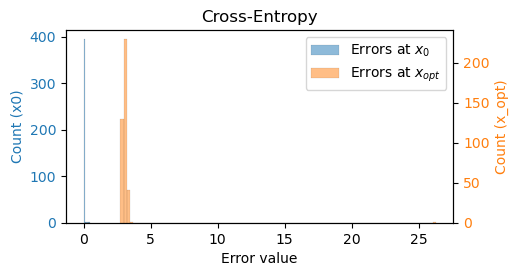

In [297]:
errors_x0 = list(results_df.error_x0_a.values)
errors_x_opt = list(results_df.error_polytope.values)

fig, ax1 = plt.subplots(figsize=(5, 2.5))
ax2 = ax1.twinx()  # second y-axis

# first histogram on ax1
ax1.hist(errors_x0, bins=5, alpha=0.5, edgecolor="black", linewidth=0.1, color="C0", label=r"Errors at $x_0$")
ax1.set_ylabel("Count (x0)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

# second histogram on ax2
ax2.hist(errors_x_opt, bins=100, alpha=0.5, edgecolor="black", linewidth=0.1, color="C1", label=r"Errors at $x_{opt}$")
ax2.set_ylabel("Count (x_opt)", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

# shared x-axis
ax1.set_xlabel("Error value")
plt.title(r"Cross-Entropy")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.savefig(f"erors_c={c}_p={p}.pdf", bbox_inches="tight")
plt.show()

### Misclassified polytopes

In [298]:
# We detect Ñ(x_opt) ≠ N(x_opt)
net_class_x_opt = results_df.net_class_x_opt
net_approx_class_x_opt = results_df.net_approx_class_x_opt

mis_idx = np.where(net_class_x_opt != net_approx_class_x_opt)[0]

print(f"There are {len(mis_idx)} misclassified polytopes at indices:\n{mis_idx}")

There are 1 misclassified polytopes at indices:
[400]


In [299]:
mis_df = results_df.iloc[mis_idx]

In [300]:
# mis_df

1 1 1 1


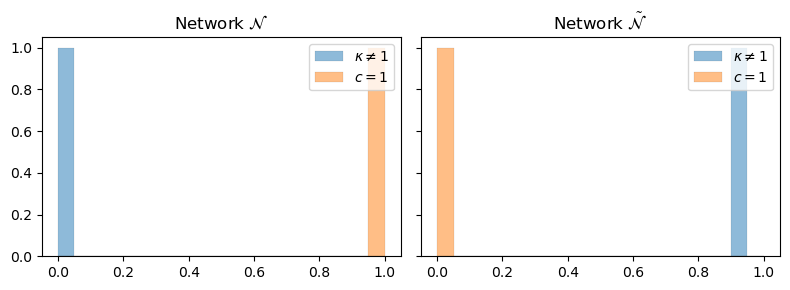

In [301]:
net_logits_x_opt = mis_df.net_logits_x_opt.apply(ast.literal_eval)
net_logits_x_opt = list(net_logits_x_opt.values)

net_class_x_opt = mis_df.net_class_x_opt
net_class_x_opt = list(map(int, net_class_x_opt))
# net_class_x_opt = list(net_class_x_opt.values)

net_approx_logits_x_opt = mis_df.net_approx_logits_x_opt.apply(ast.literal_eval)
net_approx_logits_x_opt = list(net_approx_logits_x_opt.values)

net_approx_class_x_opt =  mis_df.net_approx_class_x_opt
net_approx_class_x_opt = list(map(int, net_approx_class_x_opt))
#net_approx_class_x_opt = list(net_approx_class_x_opt.values)

# sanity check
assert (net_class_x_opt != net_approx_class_x_opt) == True

net_probs_c = [logits[c] for logits, c in zip(net_logits_x_opt, net_class_x_opt)]
net_probs_kappa = [logits[k] for logits, k in zip(net_logits_x_opt, net_approx_class_x_opt)]

net_approx_probs_c = [logits[c] for logits, c in zip(net_approx_logits_x_opt, net_class_x_opt)]
net_approx_probs_kappa = [logits[k] for logits, k in zip(net_approx_logits_x_opt, net_approx_class_x_opt)]

print(
    len(net_probs_c),
    len(net_probs_c),
    len(net_approx_probs_c),
    len(net_approx_probs_kappa)
    )

bins = np.linspace(0, 1, 21)  # 20 equal-width bins from 0 to 1

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)  # 1 row, 2 cols

# --- Left plot ---
axes[0].set_title(r"Network $\mathcal{N}$")
axes[0].hist(net_probs_kappa, bins=bins, label=rf"$\kappa \neq {c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[0].hist(net_probs_c, bins=bins, label=rf"$c={c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[0].legend(loc="upper right")

# --- Right plot ---
axes[1].set_title(r"Network $\mathcal{\tilde N}$")
axes[1].hist(net_approx_probs_kappa, bins=bins, label=rf"$\kappa \neq {c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[1].hist(net_approx_probs_c, bins=bins, label=rf"$c={c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"misclassified_polytopes_c={c}_p={p}.pdf", bbox_inches="tight")
plt.show()


In [302]:
net_class_x_opt, net_approx_class_x_opt

([1], [2])